# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [27]:
%pip install --upgrade plotly
%pip install nbformat # Install nbformat to avoid potential issues with notebook rendering

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


## Import Statements

In [28]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [29]:
# Set some pandas options to make the tables easier to read
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [30]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [31]:
dfs = {
    'df_hh_income': df_hh_income,
    'df_pct_poverty': df_pct_poverty,
    'df_pct_completed_hs': df_pct_completed_hs,
    'df_share_race_city': df_share_race_city,
    'df_fatalities': df_fatalities
}
for df_name, df in dfs.items():
  print(f"Shape of {df_name}: {df.shape}")

Shape of df_hh_income: (29322, 3)
Shape of df_pct_poverty: (29329, 3)
Shape of df_pct_completed_hs: (29329, 3)
Shape of df_share_race_city: (29268, 7)
Shape of df_fatalities: (2535, 14)


In [32]:
for df_name, df in dfs.items():
  print(f"Columns of {df_name}: {df.columns}")



Columns of df_hh_income: Index(['Geographic Area', 'City', 'Median Income'], dtype='object')
Columns of df_pct_poverty: Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')
Columns of df_pct_completed_hs: Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')
Columns of df_share_race_city: Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')
Columns of df_fatalities: Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')


In [33]:
for df_name, df in dfs.items():
  if df.isna().any().any():
    print(f"There are NaN values in {df_name}.")
  if df.duplicated().any():
    print(f"There are duplicated values in {df_name}.")

There are NaN values in df_hh_income.
There are NaN values in df_fatalities.


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [34]:
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')
df_hh_income.dropna(inplace=True)

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [35]:
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce') # Convert poverty_rate to numeric, forcing errors to NaN
df_pct_poverty.dropna(inplace=True) # Drop rows with NaN values in poverty_rate
poverty_rate = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().sort_values(ascending=False).reset_index()

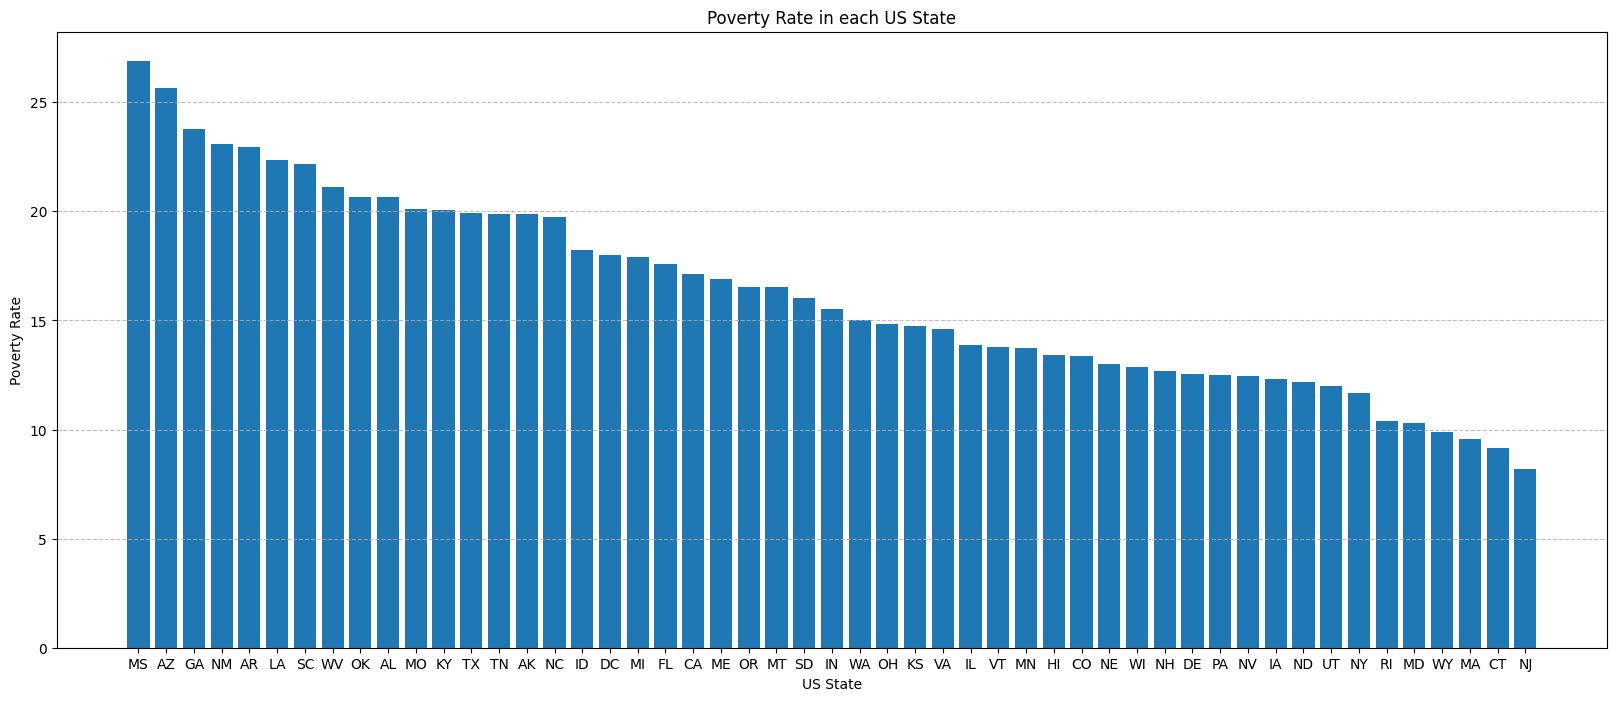

The state with the highest poverty rate is MS with a rate of 26.88%
The state with the lowest poverty rate is NJ with a rate of 8.19%


In [36]:
plt.figure(figsize=(20, 8))
plt.bar(poverty_rate['Geographic Area'], poverty_rate['poverty_rate'])
plt.xlabel("US State")
plt.ylabel("Poverty Rate")
plt.title("Poverty Rate in each US State")
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()

print(f'The state with the highest poverty rate is {poverty_rate.iloc[0]["Geographic Area"]} with a rate of {poverty_rate.iloc[0]["poverty_rate"]:.2f}%')
print(f'The state with the lowest poverty rate is {poverty_rate.iloc[-1]["Geographic Area"]} with a rate of {poverty_rate.iloc[-1]["poverty_rate"]:.2f}%')

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [37]:
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce') # Convert percent_completed_hs to numeric, forcing errors to NaN
df_pct_completed_hs.dropna(inplace=True) # Drop rows with NaN values in poverty_rate
completed_hs_rate = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().sort_values(ascending=True).reset_index() # Calculate average high school completion rate by state

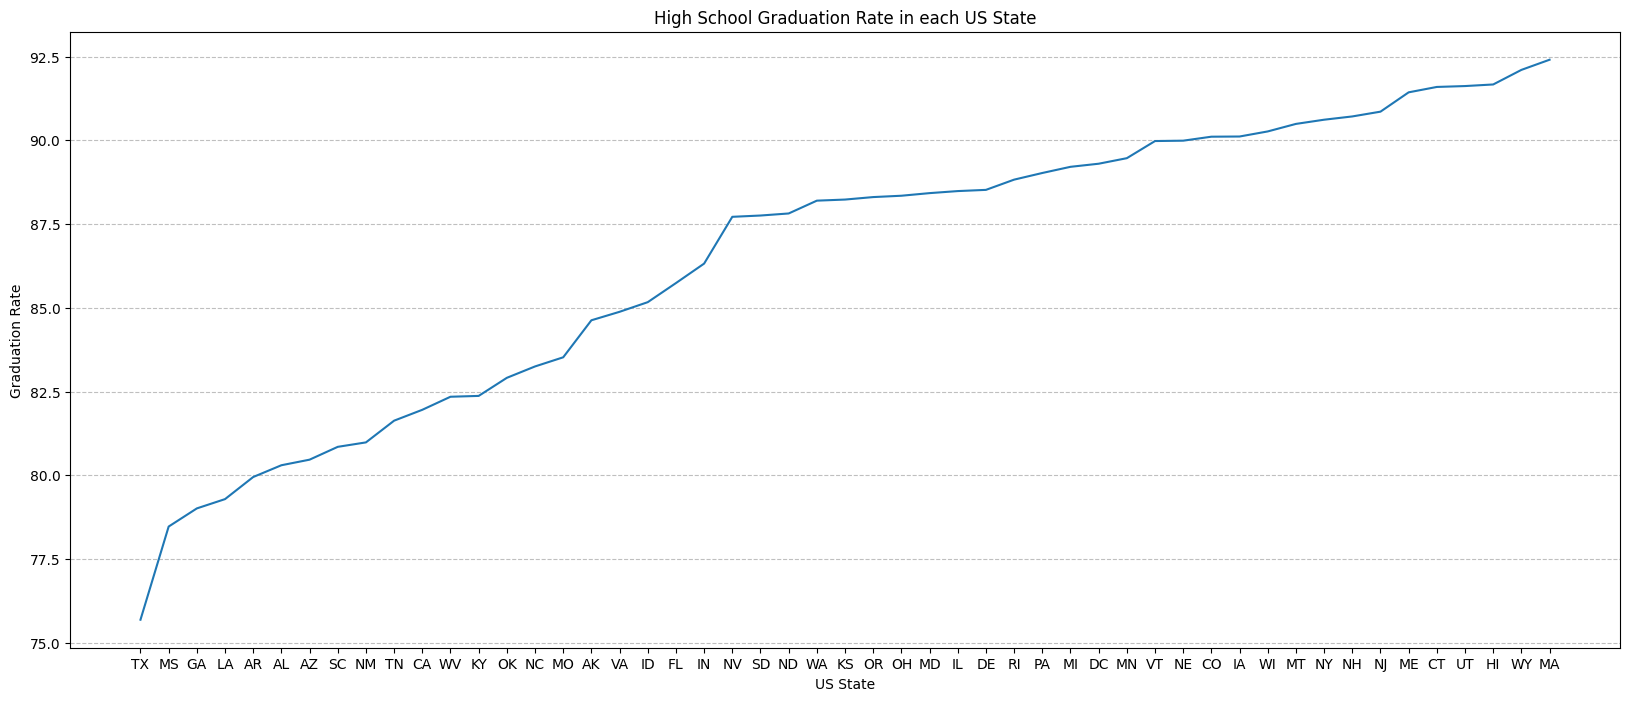

The state with the highest graduation rate is MA with a rate of 92.40%
The state with the lowest graduation rate is TX with a rate of 75.69%


In [38]:
plt.figure(figsize=(20, 8))
plt.plot(completed_hs_rate['Geographic Area'], completed_hs_rate['percent_completed_hs'])
plt.xlabel("US State")
plt.ylabel("Graduation Rate")
plt.title("High School Graduation Rate in each US State")
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()

print(f'The state with the highest graduation rate is {completed_hs_rate.iloc[-1]["Geographic Area"]} with a rate of {completed_hs_rate.iloc[-1]["percent_completed_hs"]:.2f}%')
print(f'The state with the lowest graduation rate is {completed_hs_rate.iloc[0]["Geographic Area"]} with a rate of {completed_hs_rate.iloc[0]["percent_completed_hs"]:.2f}%')

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [39]:
poverty_vs_grad_df = poverty_rate.merge(completed_hs_rate, on='Geographic Area') # Merge the two DataFrames on 'Geographic Area'
poverty_vs_grad_df.sort_values('percent_completed_hs', ascending=False, inplace=True) # Sort by graduation rate in descending order

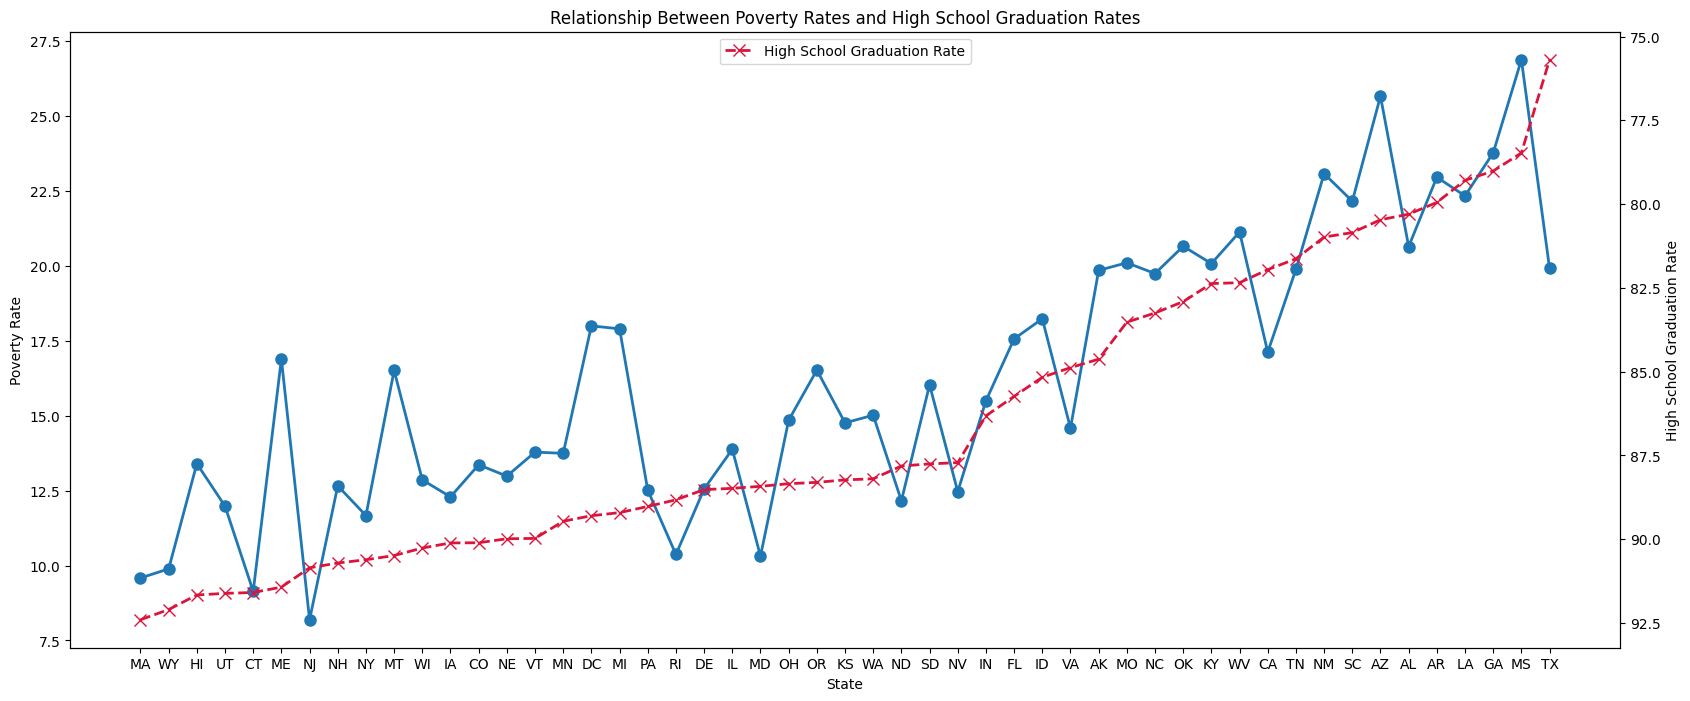

The plot above illustrates the inverse relationship between poverty rates and high school graduation rates across US states.
As the poverty rate increases, the high school graduation rate tends to decrease, indicating that higher poverty levels may be associated with lower educational attainment.


In [40]:
plt.figure(figsize=(20,8))
plt.title('Relationship Between Poverty Rates and High School Graduation Rates')

ax = plt.gca() # Get current axis
ax2 = ax.twinx() # Create a second y-axis

ax.plot(poverty_vs_grad_df['Geographic Area'], poverty_vs_grad_df['poverty_rate'], label='Poverty Rate', linestyle='-', marker='o', markersize=8, linewidth=2) # Plot poverty rate on primary y-axis

ax2.plot(poverty_vs_grad_df['Geographic Area'], poverty_vs_grad_df['percent_completed_hs'], color='crimson', label='High School Graduation Rate', linestyle='--', marker='x', markersize=8, linewidth=2) # Plot graduation rate on secondary y-axis

ax.set_ylabel('Poverty Rate')
ax.set_xlabel('State')
ax2.set_ylabel('High School Graduation Rate')

ax2.invert_yaxis() # Invert the secondary y-axis to show inverse relationship
plt.legend(loc='upper center')
ax.yaxis.grid(False)
ax2.grid(False)
plt.show()

print(f"The plot above illustrates the inverse relationship between poverty rates and high school graduation rates across US states.\nAs the poverty rate increases, the high school graduation rate tends to decrease, indicating that higher poverty levels may be associated with lower educational attainment.")

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

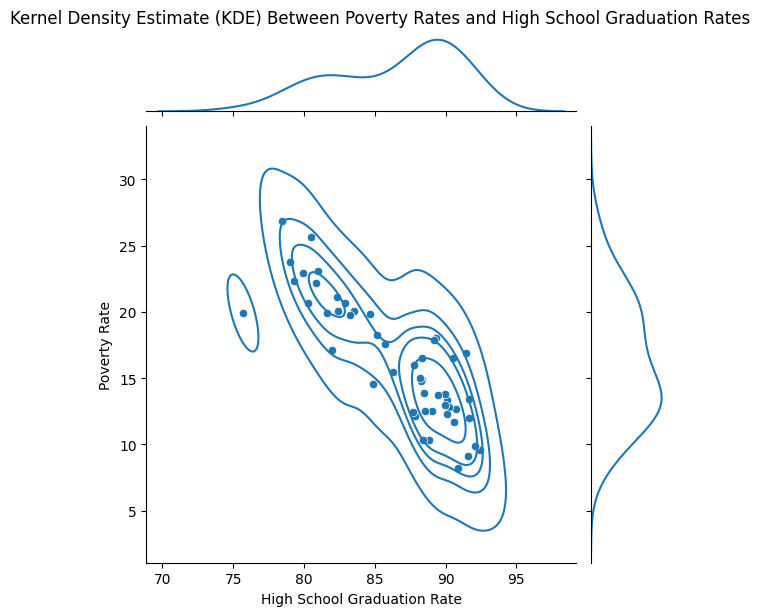

In [41]:
ax = sns.jointplot(poverty_vs_grad_df, x="percent_completed_hs", y="poverty_rate", kind='kde', levels=6) # Create a jointplot with KDE
ax1 = ax.plot_joint(sns.scatterplot) # Overlay a scatter plot on the jointplot

ax.fig.suptitle('Kernel Density Estimate (KDE) Between Poverty Rates and High School Graduation Rates', y=1.02) # Adjust title position

plt.xlabel("High School Graduation Rate")
plt.ylabel("Poverty Rate")

plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

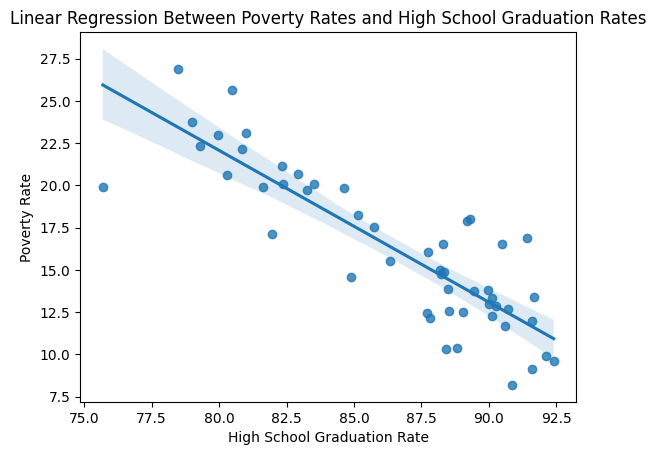

In [42]:
sns.regplot(poverty_vs_grad_df, x="percent_completed_hs", y="poverty_rate") # Create a regression plot

plt.xlabel("High School Graduation Rate")
plt.ylabel("Poverty Rate")
plt.title('Linear Regression Between Poverty Rates and High School Graduation Rates')

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [87]:
#Review 

In [ ]:
#review

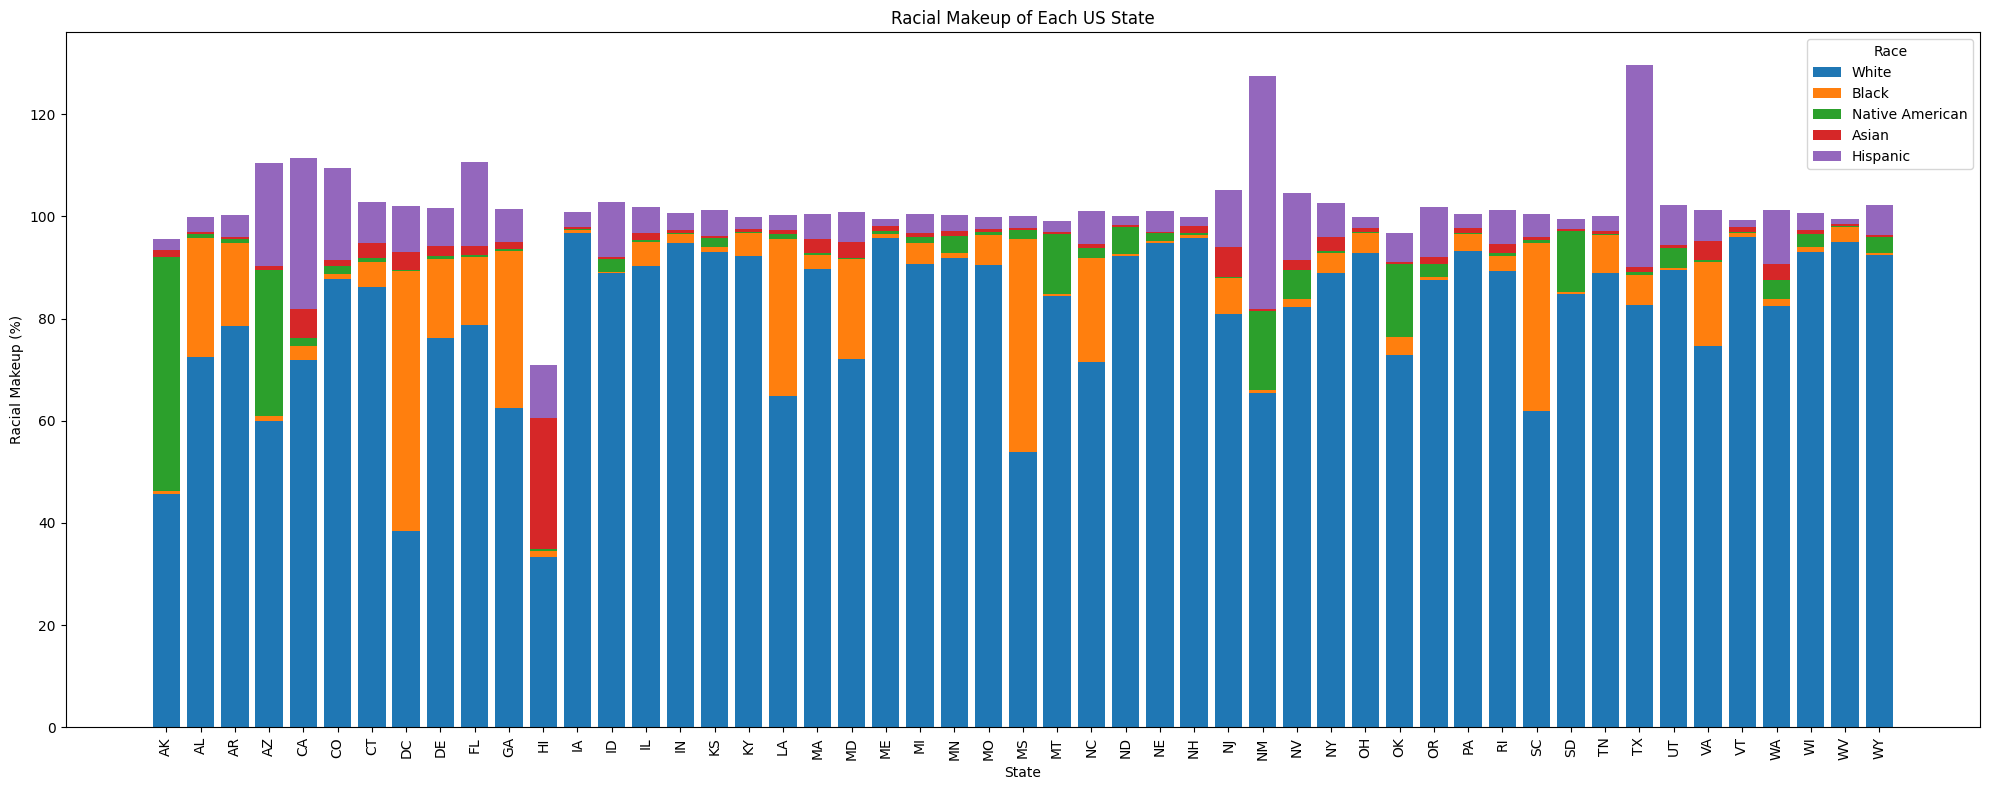

From the stacked bar chart, we can observe the racial composition of each US state.
Some states have a higher percentage of certain racial groups compared to others.
For example, states like California and Texas show a significant Hispanic population,
while states like Mississippi and Georgia have a higher percentage of Black residents.
The chart highlights the diversity across different states in the US.


In [45]:
# Stacked bar chart for racial makeup by state using Matplotlib
races = ['White', 'Black', 'Native American', 'Asian', 'Hispanic']
states = racial_makeup['Geographic area']
bottom = np.zeros(len(states))
plt.figure(figsize=(20, 8))
for race in races:
    plt.bar(states, racial_makeup[race], bottom=bottom, label=race)
    bottom += racial_makeup[race].values
plt.xlabel('State')
plt.ylabel('Racial Makeup (%)')
plt.title('Racial Makeup of Each US State')
plt.xticks(rotation=90)
plt.legend(title='Race')
plt.tight_layout()
plt.show()

print("From the stacked bar chart, we can observe the racial composition of each US state.\nSome states have a higher percentage of certain racial groups compared to others.\nFor example, states like California and Texas show a significant Hispanic population,\nwhile states like Mississippi and Georgia have a higher percentage of Black residents.\nThe chart highlights the diversity across different states in the US.")

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [46]:
deaths_by_race = df_fatalities[df_fatalities['race'].notna()]
deaths_by_race = deaths_by_race['race'].value_counts()

In [47]:
fig = px.pie(names=deaths_by_race.index,
             values=deaths_by_race.values,
             title="Deaths by Race",
             hole=0.4,)

fig.update_traces(textfont_size=15, labels=['White', 'Black', 'Native American', 'Asian', 'Hispanic'])

fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [48]:
deaths_by_gender = df_fatalities['gender'].value_counts()


In [49]:
fig = px.bar(deaths_by_gender, x=deaths_by_gender.index,
             y=deaths_by_gender.values,
             color=deaths_by_gender.index,
             title="Deaths by Gender")
fig.update_xaxes(title_text='Gender', tickvals=[0, 1], ticktext=['MEN', 'WOMEN'])
fig.update_yaxes(title_text='Death Count')

fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [50]:
age_x_manner_of_death = df_fatalities[df_fatalities['age'].notna()]
age_x_manner_of_death = age_x_manner_of_death.groupby('gender')[['age', 'manner_of_death']].value_counts().reset_index(name='count')
age_x_manner_of_death['gender'].replace({'M': 'Man', 'F': 'Woman'}, inplace=True)

C:\Users\lucas\AppData\Local\Temp\ipykernel_7624\2958956189.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [53]:
fig = px.box(age_x_manner_of_death, x='manner_of_death', y='age', color='gender', color_discrete_map={'Woman': 'red', 'Man': 'blue'})
fig.update_layout(
    title="Manner of Death by Gender and Age",
    xaxis_title="Manner of Death",
    yaxis_title="Age",
    legend_title="Gender",
)
fig.show()


# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [54]:
people_armed = df_fatalities[df_fatalities['armed'].notna()]
unarmed_percentage = ((people_armed['armed'] == 'unarmed').sum() / people_armed['armed'].value_counts().sum()) * 100
people_armed = people_armed['armed'].value_counts()
print(f"Armed people killed: {round(100 - unarmed_percentage)}%")

Armed people killed: 93%


In [55]:
fig = px.bar(people_armed, x=people_armed.index, y=people_armed.values, log_y=True, color=people_armed.values)

fig.update_layout(
    title="Type of Weapon Carried",
    xaxis_title="Weapon",
    yaxis_title="Count",
)

fig.show()

In [56]:
gun = people_armed['gun']
unarmed = people_armed['unarmed']
print(f'People armed with guns killed by the police: {gun}')
print(f'People unarmed killed by the police: {unarmed}')

People armed with guns killed by the police: 1398
People unarmed killed by the police: 171


# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [57]:
df_fatalities['race'].replace({'W': 'White', 'B': 'Black', 'N': 'Native American', 'A': 'Asian', 'H': 'Hispanic', 'O': 'Other'}, inplace=True)


C:\Users\lucas\AppData\Local\Temp\ipykernel_7624\3140229547.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [58]:
killed_by_age = df_fatalities[df_fatalities['age'].notna()]
under_25 = killed_by_age[killed_by_age['age'] < 25].value_counts().sum()
total = killed_by_age.value_counts().sum()
percentage = (under_25/total) * 100
print(f'People killed under 25 years old: {round(percentage)}%')

People killed under 25 years old: 19%


Create a seperate KDE plot for each race. Is there a difference between the distributions? 

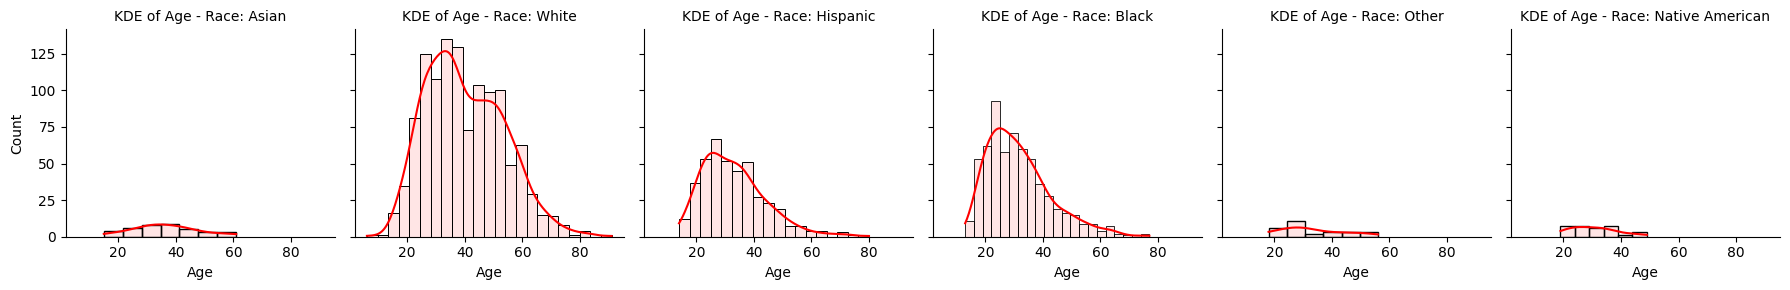

According to the KDE plots, we can observe the white, followed by the black racial groups have a wider age distribution among those killed by police.
The white group shows a significant number of deaths across various age ranges, while the black group has a noticeable peak in younger ages.
Other racial groups like Native American, Asian, and Hispanic show fewer deaths overall, with less pronounced age distributions.
This suggests that age may play a role in the likelihood of being killed by police, particularly for certain racial groups.


In [62]:
g = sns.FacetGrid(killed_by_age, col="race")
g.map(sns.histplot, 'age', kde=True, color='red', alpha=0.1)

g.set_axis_labels('Age', 'Count')
g.set_titles('KDE of Age - Race: {col_name}')

plt.show()

print("According to the KDE plots, we can observe the white, followed by the black racial groups have a wider age distribution among those killed by police.\nThe white group shows a significant number of deaths across various age ranges, while the black group has a noticeable peak in younger ages.\nOther racial groups like Native American, Asian, and Hispanic show fewer deaths overall, with less pronounced age distributions.\nThis suggests that age may play a role in the likelihood of being killed by police, particularly for certain racial groups.")

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [63]:
killed_by_race = df_fatalities[df_fatalities['race'].notna()]
killed_by_race = killed_by_race['race'].value_counts()

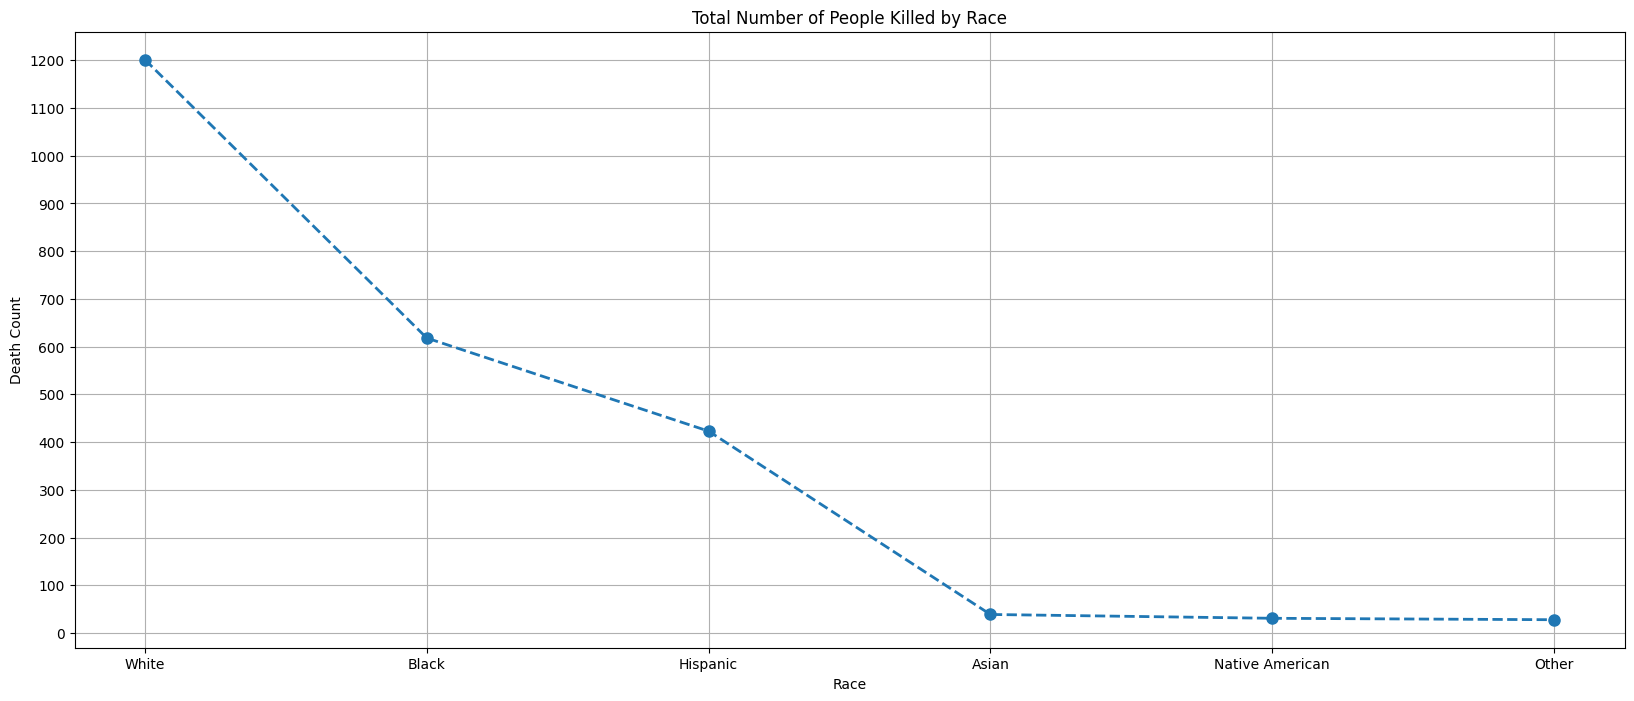

In [64]:
plt.figure(figsize=(20, 8))
plt.plot(killed_by_race, linestyle='--', marker='o', markersize=8, linewidth=2)
plt.xlabel("Race")
plt.ylabel("Death Count")
plt.title("Total Number of People Killed by Race")
plt.grid(True)
plt.yticks(range(0, killed_by_race.max(), 100))
plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [67]:
percentage = (df_fatalities['signs_of_mental_illness'].sum() / df_fatalities['signs_of_mental_illness'].count()) * 100
print(f'Percentage of People Killed with Mental Illness: {round(percentage)}%')


Percentage of People Killed with Mental Illness: 25%


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [72]:
top10_cities = df_fatalities[['state', 'city']].value_counts().head(10).reset_index(name='count')
fig = px.bar(top10_cities, x='city', y='count')

fig.update_layout(
    title="Top 10 Cities by Death Count",
    xaxis_title="City",
    yaxis_title="Death Count",
    showlegend=False
)

fig.show()


# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [73]:
merged_df = top10_cities.merge(df_fatalities, on=['state', 'city'])
merged_df = merged_df.groupby(['state', 'city', 'count'])['race'].value_counts(dropna=False).reset_index(name='death_race')
merged_df['death_race'] = round((merged_df['death_race'] / merged_df['count']) * 100)
merged_df = merged_df[merged_df['race'].isin(["Asian", "Black", "Hispanic", "Native American", "White"])]

In [74]:
cities = '|'.join(top10_cities['city'].tolist())
top10_cities_race = df_share_race_city[df_share_race_city['City'].str.contains(cities, case=False)]
for city in top10_cities['city']:
    city_variation = top10_cities_race['City'].str.contains(city, case=False)
    top10_cities_race.loc[city_variation, 'City'] = city
top10_cities_race = top10_cities_race.groupby(['Geographic area', 'City']).mean().reset_index()
top10_cities_race = top10_cities_race.merge(top10_cities, left_on=['Geographic area', 'City'], right_on=['state', 'city'])
top10_cities_race.drop(['Geographic area', 'City', 'count'], axis=1, inplace=True)
melted_df = top10_cities_race.melt(id_vars=["state", "city"], var_name="race", value_name="race_share")
race_mapping = {
    "share_white": "White",
    "share_black": "Black",
    "share_native_american": "Native American",
    "share_asian": "Asian",
    "share_hispanic": "Hispanic"
}
melted_df['race'] = melted_df['race'].replace(race_mapping)

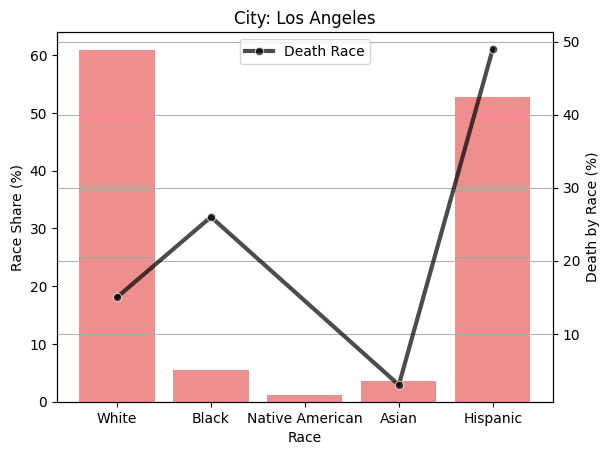

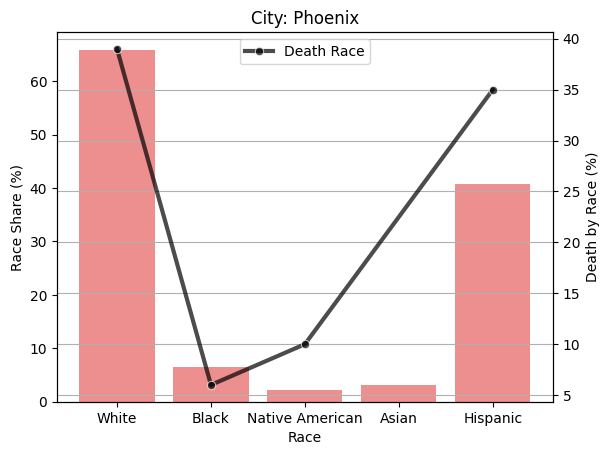

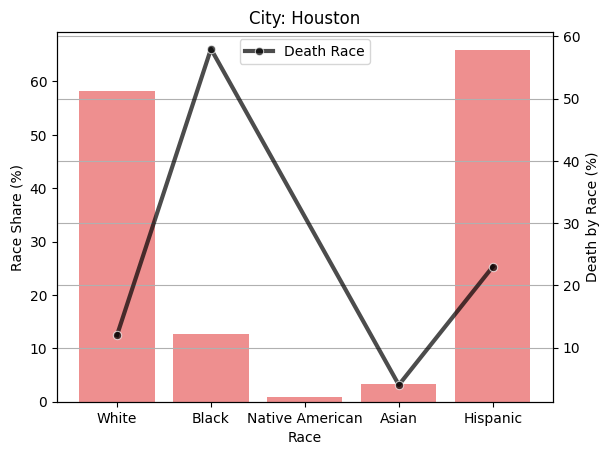

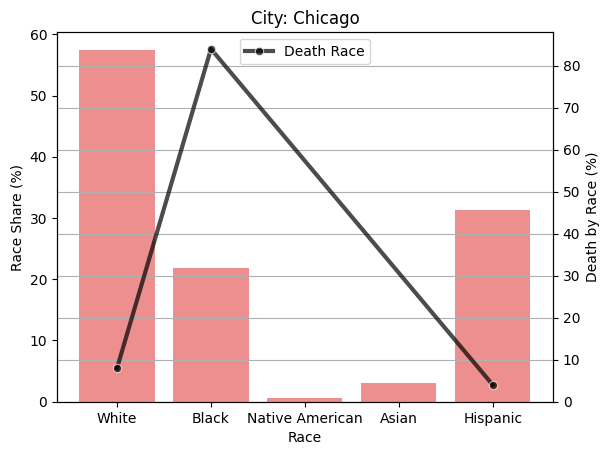

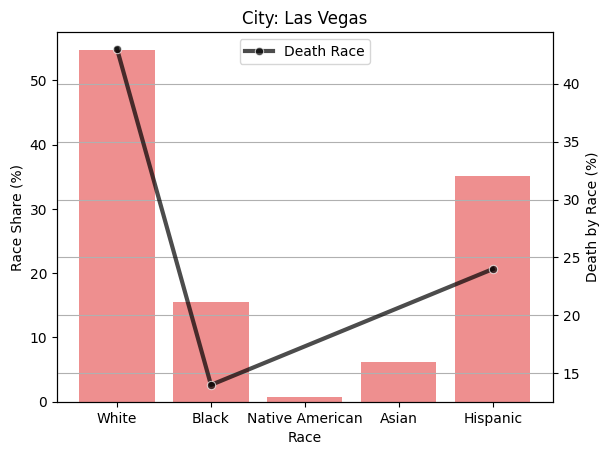

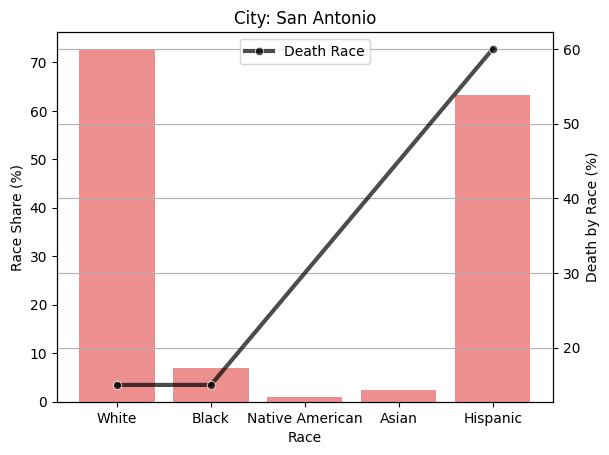

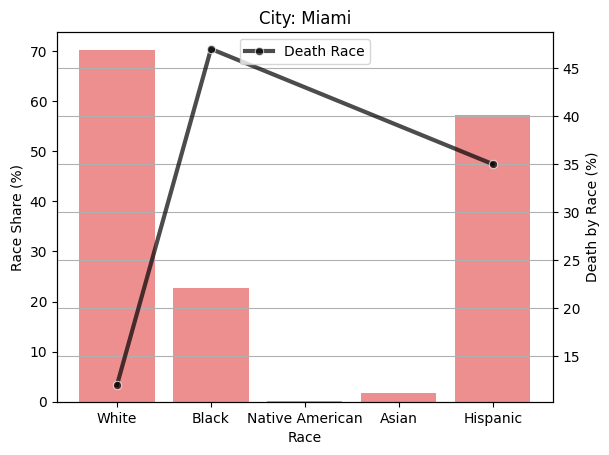

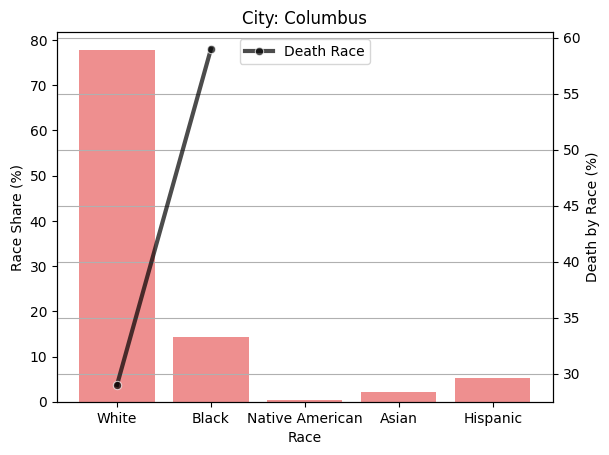

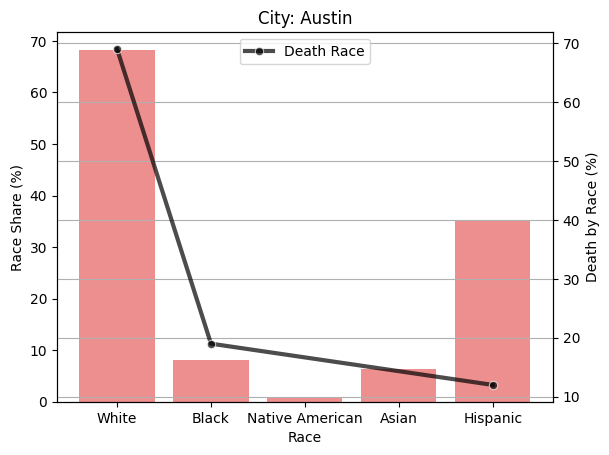

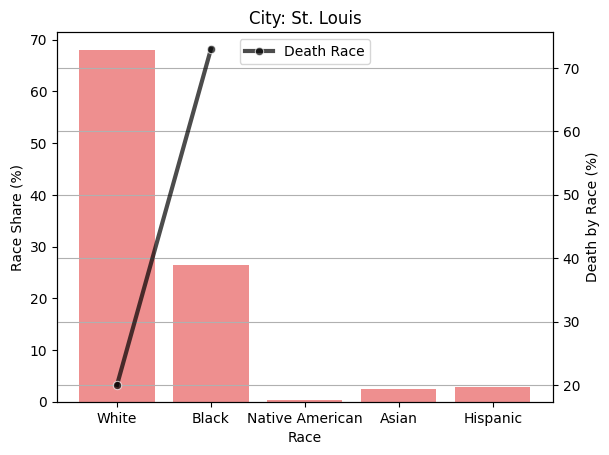

In [77]:
for city in top10_cities['city']:

    fig, ax = plt.subplots()

    sns.barplot(data=melted_df[melted_df['city'] == city], x='race', y='race_share', ax=ax, color='red', alpha=0.5)
    ax2 = ax.twinx()
    sns.lineplot(data=merged_df[merged_df['city'] == city], x='race', y='death_race', ax=ax2, color='black', alpha=0.7, marker='o', linewidth=3, label='Death Race')
    ax2.grid(None)

    ax.set_xlabel("Race")
    ax.set_ylabel("Race Share (%)")
    ax2.set_ylabel("Death by Race (%)")

    plt.legend(loc='upper center')
    plt.title(f'City: {city}')
    plt.show()

    

In [82]:
print("This plot compares the racial composition of the population in each city (represented by the red bars) with the percentage\nof deaths attributed to each racial group (represented by the black line).\nIn many cities, there is a noticeable disparity between the racial makeup and the death rates.\nFor instance, in cities like Chicago and Los Angeles, the percentage of deaths among Black individuals is\ndisproportionately high compared to their share of the population.\nThis suggests that certain racial groups may be at a higher risk of being killed by police relative to their\npopulation size in these cities.")

This plot compares the racial composition of the population in each city (represented by the red bars) with the percentage
of deaths attributed to each racial group (represented by the black line).
In many cities, there is a noticeable disparity between the racial makeup and the death rates.
For instance, in cities like Chicago and Los Angeles, the percentage of deaths among Black individuals is
disproportionately high compared to their share of the population.
This suggests that certain racial groups may be at a higher risk of being killed by police relative to their
population size in these cities.


# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [83]:
deaths_by_state = df_fatalities.groupby('state')['id'].count().reset_index(name='count')

fig = px.choropleth(deaths_by_state, locations='state', color='count', locationmode="USA-states", scope="usa", title='Police Killings by US State', color_continuous_scale='Reds')
fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [84]:
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'])


C:\Users\lucas\AppData\Local\Temp\ipykernel_7624\1937825379.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [85]:
deaths_over_time = df_fatalities.groupby('date').size().reset_index(name='count').sort_values('date')
deaths_over_time['year'] = deaths_over_time['date'].dt.year
deaths_over_time['month'] = deaths_over_time['date'].dt.month
deaths_over_time = deaths_over_time.groupby(['year', 'month'])['count'].sum().reset_index()

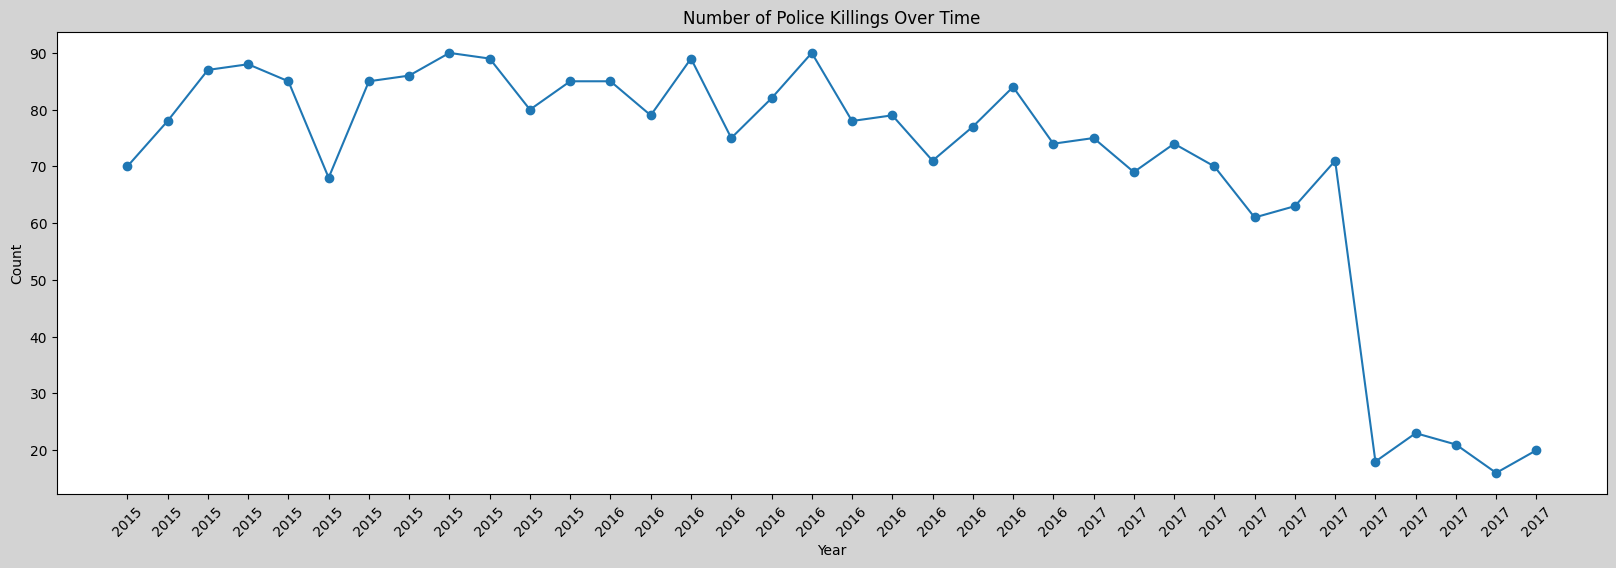

In [86]:
plt.figure(figsize=(20, 6), facecolor='lightgray')

plt.plot(deaths_over_time.index, deaths_over_time['count'], marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Number of Police Killings Over Time')

plt.xticks(deaths_over_time.index, deaths_over_time.year, rotation=45)

plt.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).

In [ ]:
## Analysis Summary

This analysis of The Washington Post's police fatalities database revealed several key findings:

1. Demographic Patterns:
    - Males were significantly more likely to be killed by police than females
    - A disproportionate number of victims were young (under 25)
    - There were notable racial disparities in police killings relative to population demographics

2. Geographic Trends:
    - Police killings varied significantly by state and city
    - Some cities showed much higher rates of police killings than others
    - There were correlations between poverty rates and police killing rates

3. Circumstantial Factors:
    - A significant percentage of victims were armed
    - Mental illness was a factor in many cases
    - The rate of killings showed some variation over time

This data highlights the complex nature of police use of force in the United States and the importance of continued documentation and analysis of these incidents.